In [17]:
import pandas as pd
df = pd.read_csv("cars_dataset-1.csv")
df.head()

,Car_ID,Brand,Model,Year,Price_USD,Fuel_Type,Transmission,Mileage_KM,Engine_CC,Horsepower,Owner_Type,City
0,1,Maruti,Swift,2020,27520.0,PETROL,manual,41975.0,1600.0,114.0,Fourth & Above Owner,Hyderabad
1,2,Volkswagen,Vento,2016,28830.0,Petrol,Automatic,60392.0,1800.0,133.0,Second Owner,Chennai
2,3,Honda,Civic,2022,23830.0,PETROL,Automatic,13595.0,1300.0,89.0,Third Owner,Delhi
3,4,BMW,3 Series,2009,21260.0,Petrol,Man,140215.0,1200.0,86.0,First Owner,Kolkata
4,5,Hyundai,Verna,2008,10140.0,PETROL,MANUAL,131754.0,1600.0,114.0,Third Owner,Pune


In [18]:
df.shape

(2240, 12)

In [19]:
df.dtypes

,0
Car_ID,int64
Brand,object
Model,object
Year,int64
Price_USD,float64
Fuel_Type,object
Transmission,object
Mileage_KM,float64
Engine_CC,float64
Horsepower,float64


In [20]:
df.isnull().sum()

,0
Car_ID,0
Brand,0
Model,0
Year,0
Price_USD,69
Fuel_Type,33
Transmission,0
Mileage_KM,56
Engine_CC,44
Horsepower,45


In [21]:
df.duplicated().sum()

np.int64(0)

In [22]:
df.drop(columns=["Car_ID"]).duplicated().sum()

np.int64(40)

In [23]:
df["Fuel_Type"].unique()

array(['PETROL', 'Petrol ', 'Diesel', 'petrol', 'Electric', 'Petrol',
       'CNG', 'DIESEL', 'hybrid', 'diesel', 'cng', 'Hybrid', nan,
       'electric', 'EV'], dtype=object)

In [24]:
df["Transmission"].unique()

array(['manual', 'Automatic', 'Man', 'MANUAL', 'Manual', 'Auto',
       'automatic', 'AUTO'], dtype=object)

In [25]:
df["Fuel_Type"] = df["Fuel_Type"].str.strip().str.title()
df["Fuel_Type"] = df["Fuel_Type"].replace({"Ev": "Electric"})

df["Transmission"] = df["Transmission"].str.strip().str.title()
df["Transmission"] = df["Transmission"].replace({"Man": "Manual", "Auto": "Automatic"})

In [26]:
df["Fuel_Type"].unique()

array(['Petrol', 'Diesel', 'Electric', 'Cng', 'Hybrid', nan], dtype=object)

In [27]:
df["Transmission"].unique()

array(['Manual', 'Automatic'], dtype=object)

In [28]:
df["Fuel_Type"] = df["Fuel_Type"].replace({"Cng": "CNG"})

In [29]:
df["Fuel_Type"].unique()

array(['Petrol', 'Diesel', 'Electric', 'CNG', 'Hybrid', nan], dtype=object)

In [30]:
df = df.drop_duplicates(subset=df.columns.difference(["Car_ID"]))
df.shape

(2200, 12)

In [31]:
for col in ["Price_USD", "Mileage_KM", "Engine_CC", "Horsepower"]:
    df[col] = df[col].fillna(df[col].median())

for col in ["Fuel_Type", "Owner_Type"]:
    df[col] = df[col].fillna(df[col].mode()[0])

In [32]:
df.isnull().sum()

,0
Car_ID,0
Brand,0
Model,0
Year,0
Price_USD,0
Fuel_Type,0
Transmission,0
Mileage_KM,0
Engine_CC,0
Horsepower,0


In [33]:
df.describe()

,Car_ID,Year,Price_USD,Mileage_KM,Engine_CC,Horsepower
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,1112.682273,2014.098182,30332.663636,94807.580909,1746.818182,121.395000
std,646.153379,5.486964,23214.424723,68137.654901,597.439484,46.720944
min,1.000000,2005.000000,5830.000000,0.000000,1000.000000,50.000000
25%,551.750000,2010.000000,14937.500000,48319.750000,1300.000000,86.000000
50%,1109.500000,2014.000000,23640.000000,90793.000000,1600.000000,110.000000
75%,1668.250000,2019.000000,36147.500000,132284.500000,2000.000000,146.250000
max,2240.000000,2023.000000,161500.000000,672626.000000,3000.000000,276.000000


In [34]:
df["Brand"].value_counts()

,count
Brand,
Ford,242
Hyundai,240
Volkswagen,230
Kia,229
Audi,226
BMW,215
Maruti,213
Mercedes,213
Toyota,205


In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

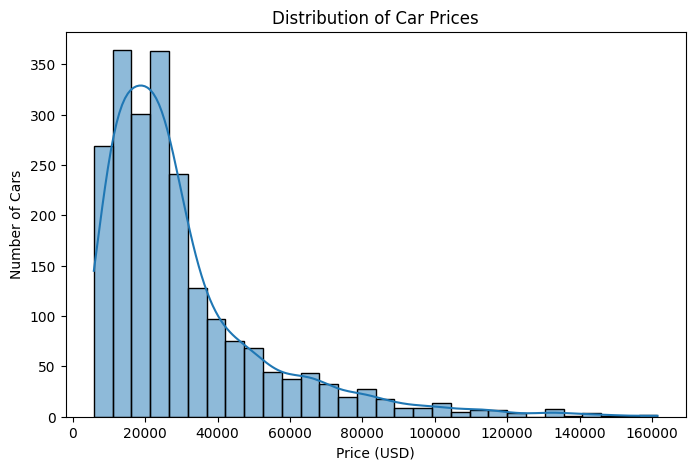

In [36]:
plt.figure(figsize=(8,5))
sns.histplot(df["Price_USD"], bins=30, kde=True)
plt.title("Distribution of Car Prices")
plt.xlabel("Price (USD)")
plt.ylabel("Number of Cars")
plt.show()

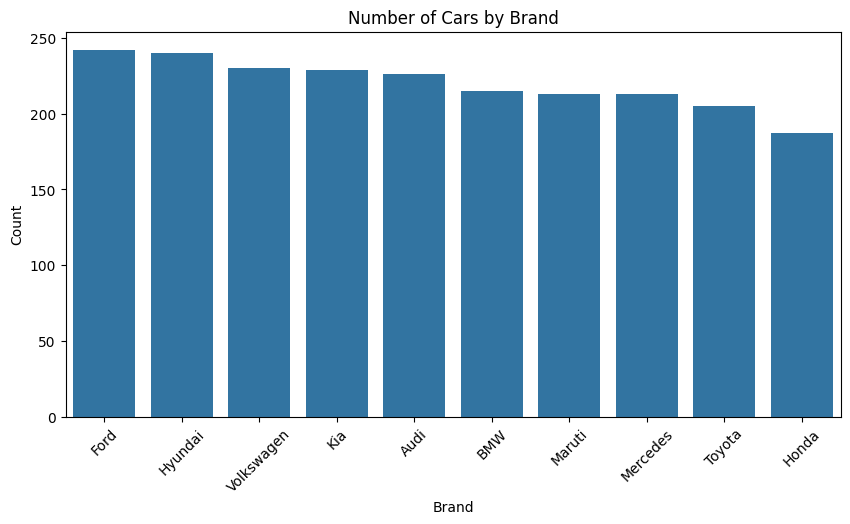

In [37]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x="Brand", order=df["Brand"].value_counts().index)
plt.title("Number of Cars by Brand")
plt.xlabel("Brand")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

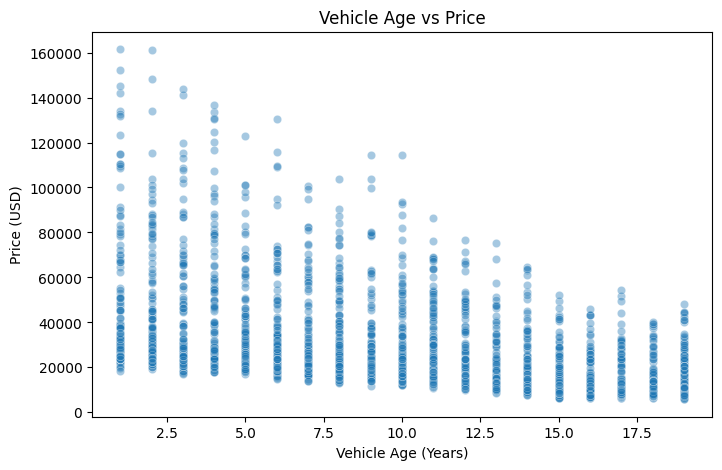

In [38]:
df["Vehicle_Age"] = 2024 - df["Year"]

plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="Vehicle_Age", y="Price_USD", alpha=0.4)
plt.title("Vehicle Age vs Price")
plt.xlabel("Vehicle Age (Years)")
plt.ylabel("Price (USD)")
plt.show()

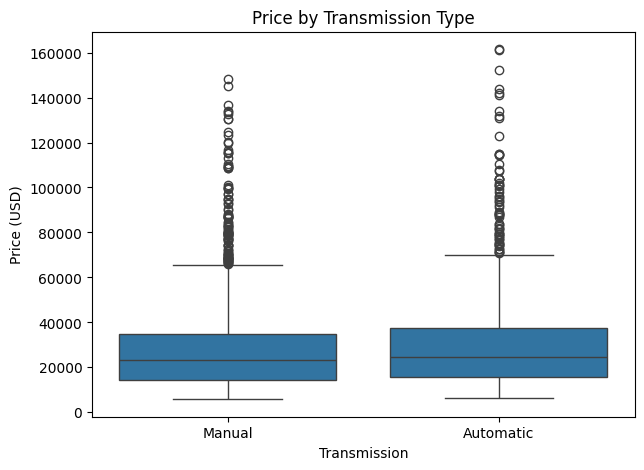

In [39]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x="Transmission", y="Price_USD")
plt.title("Price by Transmission Type")
plt.xlabel("Transmission")
plt.ylabel("Price (USD)")
plt.show()

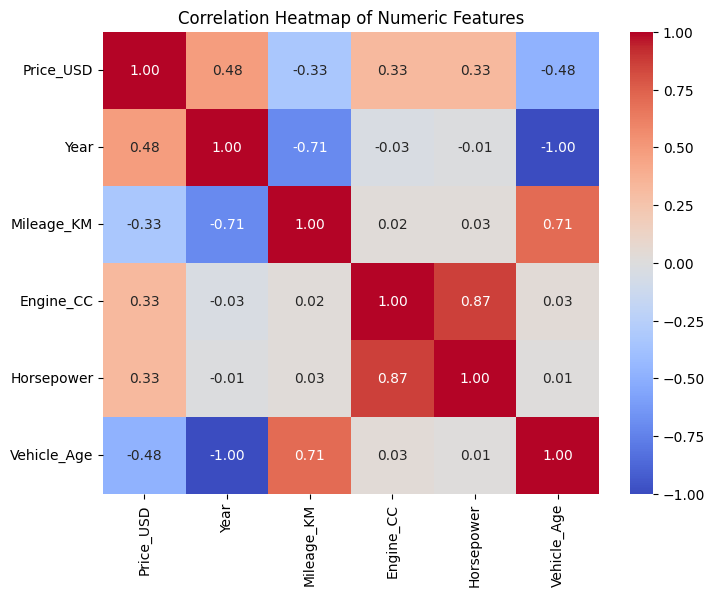

In [40]:
plt.figure(figsize=(8,6))
numeric_cols = df[["Price_USD", "Year", "Mileage_KM", "Engine_CC", "Horsepower", "Vehicle_Age"]]
sns.heatmap(numeric_cols.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

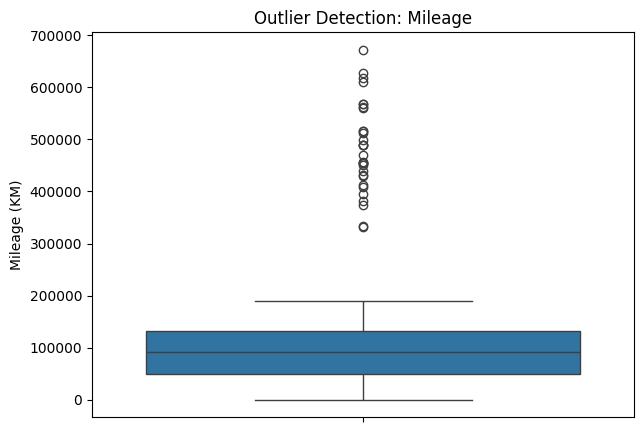

In [41]:
plt.figure(figsize=(7,5))
sns.boxplot(y=df["Mileage_KM"])
plt.title("Outlier Detection: Mileage")
plt.ylabel("Mileage (KM)")
plt.show()